In [1]:
import re
import json
import nltk
import pandas as pd


In [2]:
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("universal_tagset")


[nltk_data] Downloading package punkt to /Users/arocha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [3]:
with open("constitutions.json", "r") as f:
    constitutions = json.load(f)

In [4]:
HEADER_PATTERNS = {

    "article": [

        # ARTICLE I
        r"^\s*ARTICLE\s+[IVXLC0-9]+",

        # Article 1
        r"^\s*Article\s+[IVXLC0-9]+",

        # CHAPTER IV
        r"^\s*CHAPTER\s+[IVXLC0-9]+",

        # PART 1
        r"^\s*PART\s+[IVXLC0-9]+",

        # TITLE II
        r"^\s*TITLE\s+[IVXLC0-9]+",
    ],

    "section": [

        # Section 1
        r"^\s*Section\s+\d+",

        # SECTION 1
        r"^\s*SECTION\s+\d+",

        # Sec. 1
        r"^\s*Sec\.\s*\d+",

        # § 1
        r"^\s*§\s*\d+",

        # 1.
        r"^\s*\d+\.",

        # 1)
        r"^\s*\d+\)",
    ],

    "subsection": [

        # (a)
        r"^\s*\([a-z]\)",

        # a)
        r"^\s*[a-z]\)",

        # a.
        r"^\s*[a-z]\.",

        # (i)
        r"^\s*\([ivx]+\)",

        # i.
        r"^\s*[ivx]+\.",
    ]
}

In [5]:

def classify_line(line):
    """
    Detect structural level of a line.
    """

    for level, patterns in HEADER_PATTERNS.items():

        for pat in patterns:

            if re.match(pat, line):
                return level

    return None


In [6]:
def clean_token(token):
    """
    Normalize token text.
    """

    cleaned = re.sub(r"[\W_]+", "", token.lower())

    return cleaned

In [7]:
corpus_data = []

In [8]:
for country_id, text in constitutions.items():

    article_id = 0
    section_id = 0
    subsection_id = 0

    sent_global = 0

    lines = text.splitlines()

    for line in lines:

        line = line.strip()

        if not line:
            continue

    
        level = classify_line(line)

        if level == "article":

            article_id += 1
            section_id = 0
            subsection_id = 0

            continue

        elif level == "section":

            section_id += 1
            subsection_id = 0

            continue

        elif level == "subsection":

            subsection_id += 1

            continue

        sentences = nltk.sent_tokenize(line)

        for sent_id, sentence in enumerate(sentences):

            # Tokenization
            tokens = nltk.word_tokenize(sentence)

            # POS tagging
            pos_tags = nltk.pos_tag(tokens, tagset="universal")

            for token_id, (token_str, pos) in enumerate(pos_tags):

                term_str = clean_token(token_str)

                # Skip empty normalized tokens
                if not term_str:
                    continue

                corpus_data.append({

                    "country_id": country_id,

                    "article_id": article_id,

                    "section_id": section_id,

                    "subsection_id": subsection_id,

                    "sent_id": sent_global,

                    "token_id": token_id,

                    "token_str": token_str,

                    "term_str": term_str,

                    "pos": pos,

                    "pos_group": pos
                })

            sent_global += 1


In [9]:
CORPUS = pd.DataFrame(corpus_data)

CORPUS.set_index([
    "country_id",
    "article_id",
    "section_id",
    "subsection_id",
    "sent_id",
    "token_id"
], inplace=True)


CORPUS.head()

token_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         Afghanistan   
                                                             1                2004   
                                                     1       0            Preamble   
                                                     2       0               Share   
                                                     3       0                  In   

                                                                          term_str  \
country_id       article_id section_id subsection_id sent_id token_id                
Afghanistan_2004 0          0          0             0       0         afghanistan   
                                                             1                2004   
                                                     1       0            preamble   
                                                     2       0               share   
                                                     3       0                  in   

                                                                        pos  \
country_id       article_id section_id subsection_id sent_id token_id         
Afghanistan_2004 0          0          0             0       0          ADJ   
                                                             1          NUM   
                                                     1       0          ADJ   
                                                     2       0         NOUN   
                                                     3       0          ADP   

                                                                      pos_group  
country_id       article_id section_id subsection_id sent_id token_id            
Afghanistan_2004 0          0          0             0       0              ADJ  
                                                             1              NUM  
                                                     1       0              ADJ  
                                                     2       0             NOUN  
                                                     3       0              ADP

In [10]:
structure_report = []

for country_id, group in CORPUS.groupby(level=0):

    idx = group.index

    structure_report.append({

        "country_id": country_id,

        "tokens": len(group),

        "articles":
            idx.get_level_values("article_id").nunique(),

        "sections":
            idx.get_level_values("section_id").nunique(),

        "subsections":
            idx.get_level_values("subsection_id").nunique(),

        "sentences":
            idx.get_level_values("sent_id").nunique(),
    })

STRUCTURE = pd.DataFrame(structure_report)

print("\n--- STRUCTURE REPORT ---\n")
print(STRUCTURE)


flat_docs = STRUCTURE[
    (STRUCTURE["articles"] <= 1) |
    (STRUCTURE["sections"] <= 1)
]

print("\n--- POSSIBLE PARSING FAILURES ---\n")

if flat_docs.empty:
    print("No obvious failures detected.")
else:
    print(flat_docs)




--- STRUCTURE REPORT ---

           country_id  tokens  articles  sections  subsections  sentences
0    Afghanistan_2004    9059       163         4            1        597
1        Albania_2008    1715       209         3            1        287
2        Algeria_2008    9589       196         3            1        633
3        Andorra_1993    2440       117         6            1        253
4         Angola_2010    3284       250         5            3        428
..                ...     ...       ...       ...          ...        ...
187      Vanuatu_1983    2004        18        32            1        174
188    Venezuela_2009   28646       360        17            1       1554
189        Yemen_2001    7985       163         1            1        571
190       Zambia_2009    3798       140        11            6        272
191     Zimbabwe_2013    7561        71        76           15        764

[192 rows x 6 columns]

--- POSSIBLE PARSING FAILURES ---

                         

In [12]:
STRUCTURE

,country_id,tokens,articles,sections,subsections,sentences
0,Afghanistan_2004,9059,163,4,1,597
1,Albania_2008,1715,209,3,1,287
2,Algeria_2008,9589,196,3,1,633
3,Andorra_1993,2440,117,6,1,253
4,Angola_2010,3284,250,5,3,428
...,...,...,...,...,...,...
187,Vanuatu_1983,2004,18,32,1,174
188,Venezuela_2009,28646,360,17,1,1554
189,Yemen_2001,7985,163,1,1,571
190,Zambia_2009,3798,140,11,6,272


In [11]:
flat_docs

,country_id,tokens,articles,sections,subsections,sentences
8,Australia_1985,10122,1,144,6,444
9,Austria_2009,4675,1,192,5,729
18,Benin_1990,11089,173,1,1,669
26,Burkina_Faso_2012,9687,201,1,1,710
28,Cambodia_1999,8236,159,1,1,618
33,Chad_2005,11068,226,1,1,887
37,Comoros_2009,6059,65,1,1,359
38,Congo_2001,10790,211,1,1,752
40,Cote_DIvoire_2009,7632,149,1,1,539
42,Cuba_2002,8939,153,1,7,515


In [14]:
CORPUS.reset_index().to_csv(
    "const_TOKEN.csv",
    index=False
)

print("\nToken table saved.")


Token table saved.


In [29]:
len(CORPUS)

1712119

In [16]:
import numpy as np
VOCAB = CORPUS.term_str.value_counts().to_frame('n').sort_index()
VOCAB.index.name = 'term_str'
VOCAB['n_chars'] = VOCAB.index.str.len()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = -np.log2(VOCAB.p)
VOCAB

,n,n_chars,p,i
term_str,,,,
0,5,1,2.920358e-06,18.385423
00,6,2,3.504429e-06,18.122389
000,1,3,5.840716e-07,20.707352
00w,1,3,5.840716e-07,20.707352
01,7,2,4.088501e-06,17.899997
...,...,...,...,...
órdenes,1,7,5.840716e-07,20.707352
órganos,1,7,5.840716e-07,20.707352
ô,1,1,5.840716e-07,20.707352


In [17]:
VOCAB['max_pos'] = CORPUS[['term_str','pos']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['max_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB

,n,n_chars,p,i,max_pos,max_pos_group
term_str,,,,,,
0,5,1,2.920358e-06,18.385423,NUM,NUM
00,6,2,3.504429e-06,18.122389,NUM,NUM
000,1,3,5.840716e-07,20.707352,NUM,NUM
00w,1,3,5.840716e-07,20.707352,NUM,NUM
01,7,2,4.088501e-06,17.899997,NUM,NUM
...,...,...,...,...,...,...
órdenes,1,7,5.840716e-07,20.707352,NOUN,NOUN
órganos,1,7,5.840716e-07,20.707352,ADJ,ADJ
ô,1,1,5.840716e-07,20.707352,NOUN,NOUN


In [18]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))

In [19]:
Q = VOCAB.groupby(VOCAB.n_pos >= 2).agg({'n': ['count','sum']})
Q = ((Q / Q.sum()) * 100).round().astype(int)
Q.columns = ['types', 'tokens']
Q.index = ['unambiguous','ambiguous']
Q.style.background_gradient()

,types,tokens
unambiguous,82,22
ambiguous,18,78


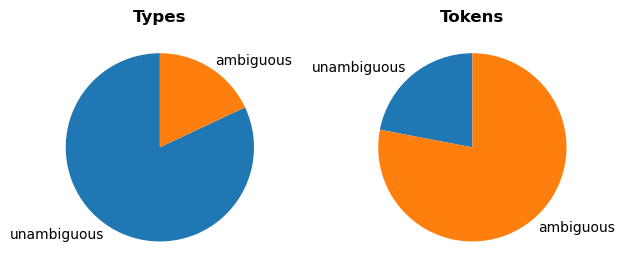

In [21]:
import matplotlib.pyplot as plt

ax = Q.plot.pie(subplots=True, legend=False, startangle=90)
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_title('Types', fontweight='bold')
ax[1].set_title('Tokens', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
nltk.download('stopwords')
sw = pd.DataFrame(nltk.corpus.stopwords.words('english'), columns=['term_str'])
sw = sw.reset_index().set_index('term_str')
sw.columns = ['dummy']
sw.dummy = 1
sw.sample(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arocha/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,dummy
term_str,
here,1
and,1
hasn,1
hasn't,1
her,1


In [25]:
VOCAB['stop'] = sw
VOCAB['stop'] = VOCAB['stop'].fillna(0).astype('int')

In [26]:
from nltk.stem.porter import PorterStemmer
stemmer1 = PorterStemmer()
VOCAB['stem_porter'] = VOCAB.apply(lambda x: stemmer1.stem(x.name), 1)

from nltk.stem.snowball import SnowballStemmer
stemmer2 = SnowballStemmer("english")
VOCAB['stem_snowball'] = VOCAB.apply(lambda x: stemmer2.stem(x.name), 1)

from nltk.stem.lancaster import LancasterStemmer
stemmer3 = LancasterStemmer()
VOCAB['stem_lancaster'] = VOCAB.apply(lambda x: stemmer3.stem(x.name), 1)

In [27]:
VOCAB.to_csv('const_VOCAB.csv')

In [28]:
VOCAB.head()

,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,stop,stem_porter,stem_snowball,stem_lancaster
term_str,,,,,,,,,,,,,,
0,5,1,2.920358e-06,18.385423,NUM,NUM,1,{NUM},1,{NUM},0,0,0,0
00,6,2,3.504429e-06,18.122389,NUM,NUM,1,{NUM},1,{NUM},0,00,00,00
000,1,3,5.840716e-07,20.707352,NUM,NUM,1,{NUM},1,{NUM},0,000,000,000
00w,1,3,5.840716e-07,20.707352,NUM,NUM,1,{NUM},1,{NUM},0,00w,00w,00w
01,7,2,4.088501e-06,17.899997,NUM,NUM,1,{NUM},1,{NUM},0,01,01,01


In [30]:
len(VOCAB)

24136

In [36]:
doc_terms = (
    CORPUS
    .reset_index()[['country_id', 'term_str']]
    .drop_duplicates()
)

# df = number of documents containing term
df = (
    doc_terms
    .groupby('term_str')
    .size()
    .rename('df')
)


In [37]:
N_docs = (
    CORPUS
    .reset_index()['country_id']
    .nunique()
)

In [38]:
VOCAB = VOCAB.join(df)

# fill missing df values
VOCAB['df'] = VOCAB['df'].fillna(0)


In [39]:
VOCAB['idf'] = np.log(N_docs / VOCAB['df'])

In [40]:
VOCAB['dfidf'] = VOCAB['df'] * VOCAB['idf']

In [45]:
VOCAB[['df', 'idf', 'dfidf']].sort_values(
    'dfidf',
    ascending=False
).head(20).index

Index(['limitations', 'address', 'payment', 'formation', 'placed', 'vi',
       'exercises', 'october', 'approve', 'area', 'included', 'direction',
       'press', 'enforcement', 'obtain', 'progress', 'meets', 'engage',
       'arising', 'structure'],
      dtype='object', name='term_str')